# Automatic Coarsening Test

Test de coarsening automatique à partir d'un maillage Telemac.

Version actuelle : pas de `res`, pas de `h_initial`. Les berges / digues / remblais sont approximés uniquement par les ruptures topographiques.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from matplotlib.collections import LineCollection

def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / 'python' / 'simple_transfer_coarsening.py').exists():
            return path
    raise RuntimeError('Cannot find gnn_modulus_test project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from python.python_code.data_manip.formats.serafin_file import SerafinFile
from python.simple_transfer_coarsening import (
    NORMAL,
    PRESCRIBED_H,
    PRESCRIBED_Q,
    WALL_BOUNDARY,
    build_simple_coarse_mesh,
    get_preserve_node_mask,
    get_topo_barrier_node_mask,
    mesh_scale_stats,
    unique_edges_from_triangles,
)

PROJECT_ROOT

PosixPath('/users/m24046/m24046mrcr/gnn_modulus_test')

In [34]:
!ls /work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5

08_T2V6_KV4_Busev2_Q5.res     T2_s08_Q5.sh  out_fortran
Maille_T2V6_BuseV3.txt	      cas	    slurm-15050426.out
Sarce_PriseLac_Q5_V1.sources  cas.conlim    slurm-15051589.out
T2V6_KV4_BuseV2.geo	      condInit.ser
T2_Q5_V1.liq		      fortran.f


## 1. Paramètres

In [18]:
# À remplir.
MESH_SLF = '/work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5/T2V6_KV4_BuseV2.geo'  
CLI_FILE = '/work/m24046/m24046mrcr/Aube/08_T2V6_KV4_Busev2_Q5/cas.conlim'  

# Coarsening.
SPACING = 80.0
PRESERVE_EXPAND = 1

# Laisser None pour utiliser les seuils automatiques par quantile.
DZ_MIN = None
SLOPE_MIN = None

# Visualisation.
MAX_SCATTER_POINTS = 250_000
MAX_EDGES_TO_DRAW = 80_000

# Export coarse mesh.
COARSE_SLF = '/work/m24046/m24046mrcr/Aube/automatic_coarse_mesh_T2.slf'
OVERWRITE_COARSE_SLF = True

## 2. Utilitaires

In [19]:
def require_path(path_like: str, name: str) -> Path:
    if not path_like:
        raise ValueError(f'{name} is empty. Fill it in the parameter cell.')
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f'{name} does not exist: {path}')
    return path


def read_first_available(telemac: TelemacFile, names: list[str], timestep: int = 0):
    last_error = None
    for name in names:
        try:
            return telemac.get_data_value(name, timestep)
        except Exception as exc:
            last_error = exc
    raise KeyError(f'None of these variables were found: {names}') from last_error


def extract_boundary_type(telemac_with_cli: TelemacFile) -> np.ndarray:
    """Return integer node types: 0 normal, 1 H, 2 Q, 3 wall."""
    n_points = telemac_with_cli.tri.x.shape[0]
    boundary_type = np.zeros(n_points, dtype=np.int64)
    nbor, lihbor, liubor, livbor, _ = telemac_with_cli.get_bnd_info()

    code_to_type = {
        (5, 4, 4): PRESCRIBED_H,
        (4, 5, 5): PRESCRIBED_Q,
        (2, 2, 2): WALL_BOUNDARY,
    }

    unknown_codes = {}
    for node, lh, lu, lv in zip(nbor, lihbor, liubor, livbor):
        code = (int(lh), int(lu), int(lv))
        node_type = code_to_type.get(code)
        if node_type is None:
            unknown_codes[code] = unknown_codes.get(code, 0) + 1
            continue
        boundary_type[int(node)] = node_type

    if unknown_codes:
        print('Unknown boundary codes left as NORMAL:', unknown_codes)

    return boundary_type


def sample_indices(n: int, max_points: int) -> np.ndarray:
    if n <= max_points:
        return np.arange(n)
    rng = np.random.default_rng(0)
    return rng.choice(n, size=max_points, replace=False)


def plot_node_mask(xy, mask, title, max_points=MAX_SCATTER_POINTS):
    idx = sample_indices(len(xy), max_points)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(xy[idx, 0], xy[idx, 1], s=0.15, c='lightgray', label='fine nodes')
    ax.scatter(xy[mask, 0], xy[mask, 1], s=1.5, c='red', label='mask')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | selected={int(mask.sum())}')
    ax.legend(loc='best')
    plt.show()


def plot_edges(ax, xy, edges, color='black', linewidth=0.2, alpha=0.4, max_edges=MAX_EDGES_TO_DRAW):
    if len(edges) == 0:
        return
    idx = sample_indices(len(edges), max_edges)
    segments = xy[edges[idx]]
    lc = LineCollection(segments, colors=color, linewidths=linewidth, alpha=alpha)
    ax.add_collection(lc)


def plot_coarse_support(fine_xy, coarse_xy, coarse_edges, title='coarse support'):
    idx = sample_indices(len(fine_xy), MAX_SCATTER_POINTS)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(fine_xy[idx, 0], fine_xy[idx, 1], s=0.08, c='lightgray', label='fine nodes')
    plot_edges(ax, coarse_xy, coarse_edges, color='tab:blue', linewidth=0.35, alpha=0.55)
    ax.scatter(coarse_xy[:, 0], coarse_xy[:, 1], s=1.0, c='black', label='coarse nodes')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend(loc='best')
    plt.show()


def plot_regions(xy, labels, title, max_points=MAX_SCATTER_POINTS):
    idx = sample_indices(len(xy), max_points)
    fig, ax = plt.subplots(figsize=(10, 10))
    sc = ax.scatter(xy[idx, 0], xy[idx, 1], c=labels[idx], s=0.25, cmap='tab20')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | regions={len(np.unique(labels))}')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    plt.show()


def plot_coarse_triangulation(coarse_xy, coarse_triangles, title='coarse Delaunay triangulation'):
    fig, ax = plt.subplots(figsize=(10, 10))
    if len(coarse_triangles) > 0:
        triang = mtri.Triangulation(coarse_xy[:, 0], coarse_xy[:, 1], coarse_triangles)
        ax.triplot(triang, color='tab:blue', linewidth=0.35, alpha=0.7)
    ax.scatter(coarse_xy[:, 0], coarse_xy[:, 1], s=1.0, c='black')
    ax.set_aspect('equal')
    ax.set_title(f'{title} | triangles={len(coarse_triangles)}')
    plt.show()


def write_coarse_slf(output_path, coarse, overwrite=True):
    """Write the coarse support as a simple SERAFIN .slf file."""
    output_path = Path(output_path).expanduser()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        if not overwrite:
            raise FileExistsError(f'Output already exists: {output_path}')
        output_path.unlink()

    coarse_xy = np.asarray(coarse.xy, dtype=np.float64)
    coarse_triangles = np.asarray(coarse.triangles, dtype=np.int32)
    coarse_z = np.asarray(coarse.z, dtype=np.float64)

    if coarse.strickler is None:
        coarse_strickler = np.zeros(len(coarse_xy), dtype=np.float64)
        print('coarse.strickler is None: writing FROTTEMENT=0.0')
    else:
        coarse_strickler = np.asarray(coarse.strickler, dtype=np.float64)

    if len(coarse_triangles) == 0:
        raise ValueError('Cannot write .slf without triangles.')

    variable_names = ['FOND', 'FROTTEMENT']
    variable_units = ['M', '']
    variable_values = [coarse_z, coarse_strickler]

    slf = SerafinFile(str(output_path), 'SERAFIN', access='w')
    slf.set_header(
        title='COARSE MESH',
        nvar=len(variable_names),
        var_name=variable_names,
        var_unit=variable_units,
    )

    ipobo = np.full(len(coarse_xy), -1, dtype=np.int32)
    knolg = np.arange(len(coarse_xy), dtype=np.int32)
    slf.set_mesh(
        mesh_dim=2,
        typ_elem=None,
        ndp=3,
        nptfr=0,
        nptir=0,
        nelem=len(coarse_triangles),
        npoin=len(coarse_xy),
        ikles=coarse_triangles,
        ipobo=ipobo,
        knolg=knolg,
        coordx=coarse_xy[:, 0],
        coordy=coarse_xy[:, 1],
        nplan=1,
        date=[2026, 4, 20],
        time=[0, 0, 0],
        x_orig=0,
        y_orig=0,
    )

    for i, (name, unit, values) in enumerate(zip(variable_names, variable_units, variable_values)):
        slf.add_data(name, unit, time=0.0, record=0, first_var=(i == 0), values=values)

    slf.close()
    return output_path

## 3. Chargement du maillage et du CLI

In [20]:
mesh_path = require_path(MESH_SLF, 'MESH_SLF')
cli_path = require_path(CLI_FILE, 'CLI_FILE')

mesh = TelemacFile(str(mesh_path))
mesh_with_cli = TelemacFile(str(mesh_path), bnd_file=str(cli_path))

xy = np.column_stack([mesh.tri.x, mesh.tri.y])
triangles = np.asarray(mesh.tri.triangles, dtype=np.int64)
z = read_first_available(mesh, ['FOND', 'BOTTOM'], timestep=0).astype(np.float64)

try:
    strickler = read_first_available(mesh, ['FROTTEMENT', 'FRICTION', 'STRICKLER'], timestep=0).astype(np.float64)
except KeyError:
    strickler = None
    print('No friction/Strickler variable found; strickler=None')

boundary_type = extract_boundary_type(mesh_with_cli)

print('nodes:', len(xy))
print('triangles:', len(triangles))
print('z:', z.shape, float(np.nanmin(z)), float(np.nanmax(z)))
print('boundary_type counts:', dict(zip(*np.unique(boundary_type, return_counts=True))))

nodes: 313521
triangles: 623905
z: (313521,) 112.86008810522175 244.60697543121677
boundary_type counts: {0: 310312, 1: 100, 2: 10, 3: 3099}


## 4. Maillage fin

fine_edges: (937462, 2)


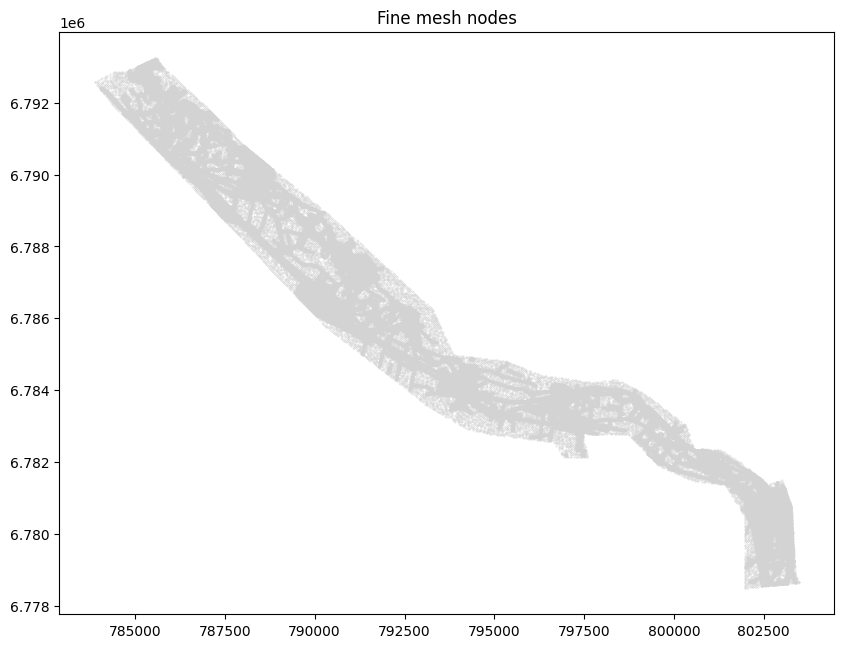

In [21]:
fine_edges = unique_edges_from_triangles(triangles)
print('fine_edges:', fine_edges.shape)

fig, ax = plt.subplots(figsize=(10, 10))
idx = sample_indices(len(xy), MAX_SCATTER_POINTS)
ax.scatter(xy[idx, 0], xy[idx, 1], s=0.1, c='lightgray')
ax.set_aspect('equal')
ax.set_title('Fine mesh nodes')
plt.show()

## 5. Étape topo_barrier_node_mask

used_dz_min: 2.2267563926079452
used_slope_min: 0.39153152915302086
topo_edge_mask edges: 6404


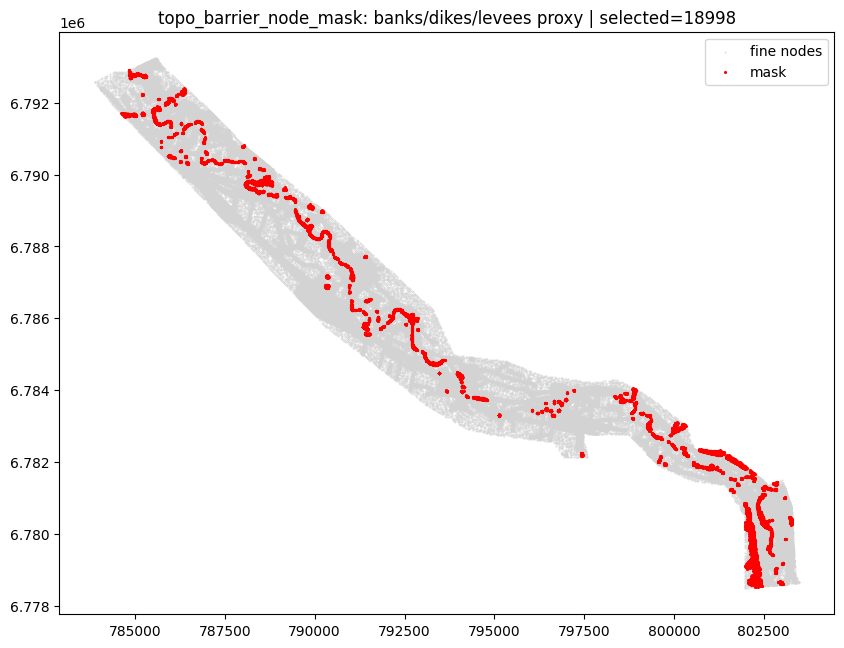

In [22]:
topo_barrier_node_mask, topo_edge_mask, used_dz_min, used_slope_min = get_topo_barrier_node_mask(
    xy=xy,
    edges=fine_edges,
    z=z,
    dz_min=DZ_MIN,
    slope_min=SLOPE_MIN,
    expand=PRESERVE_EXPAND,
)

print('used_dz_min:', used_dz_min)
print('used_slope_min:', used_slope_min)
print('topo_edge_mask edges:', int(topo_edge_mask.sum()))

plot_node_mask(xy, topo_barrier_node_mask, 'topo_barrier_node_mask: banks/dikes/levees proxy')

## 6. Étape preserve_node_mask

boundary nodes: 3209
topo barrier nodes: 18998
preserved nodes: 22125


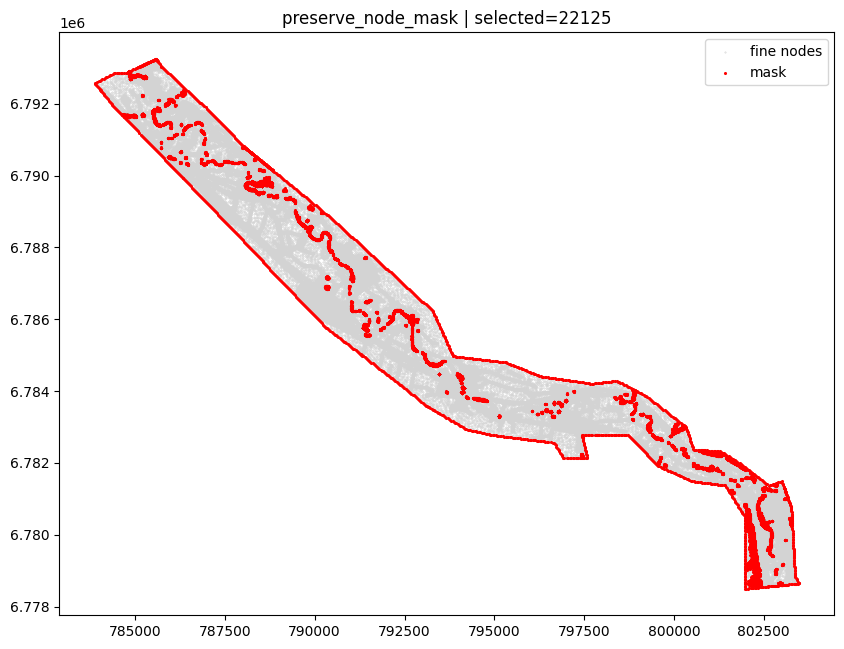

In [23]:
preserve_node_mask = get_preserve_node_mask(
    boundary_type=boundary_type,
    topo_barrier_node_mask=topo_barrier_node_mask,
)

print('boundary nodes:', int((boundary_type != NORMAL).sum()))
print('topo barrier nodes:', int(topo_barrier_node_mask.sum()))
print('preserved nodes:', int(preserve_node_mask.sum()))

plot_node_mask(xy, preserve_node_mask, 'preserve_node_mask')

## 7. Construction du support coarse

In [24]:
coarse = build_simple_coarse_mesh(
    xy=xy,
    triangles=triangles,
    z=z,
    boundary_type=boundary_type,
    strickler=strickler,
    spacing=SPACING,
    preserve_expand=PRESERVE_EXPAND,
    dz_min=DZ_MIN,
    slope_min=SLOPE_MIN,
)

stats = mesh_scale_stats(coarse.xy, coarse.undirected_edges)
stats

Simple Telemac-style coarsening: fine_nodes=313521 coarse_nodes=28820 triangles=52946 removed_outside_domain=4609 undirected_edges=83316 spacing=80.0 dz_min=2.23 slope_min=0.392


{'nodes': 28820.0,
 'undirected_edges': 83316.0,
 'mean_edge_m': 31.068688340749752,
 'median_edge_m': 13.302244202810963,
 'max_edge_m': 168.4923124808372,
 'r10_median_m': 112.1459941066812,
 'r10_mean_m': 283.71130131629934,
 'r10_max_m': 1140.6960125551623}

## 8. Visualisation des régions

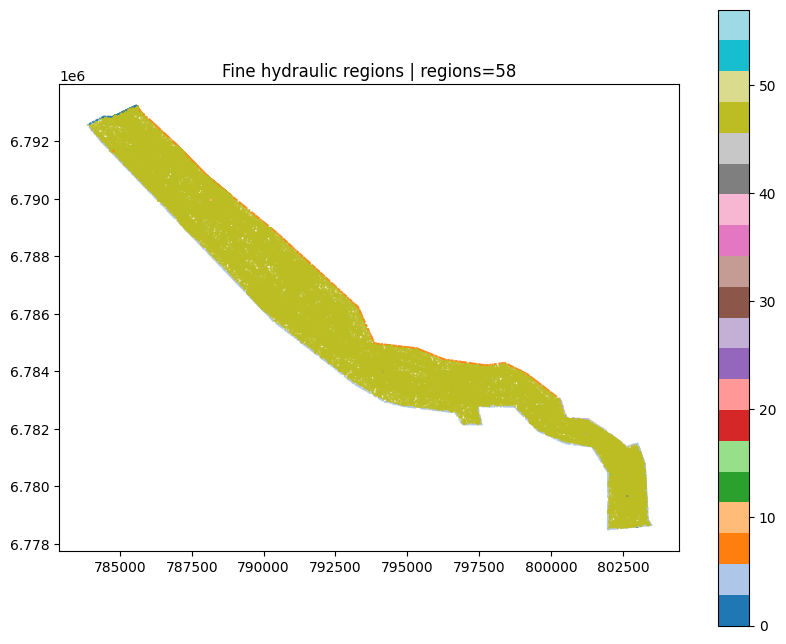

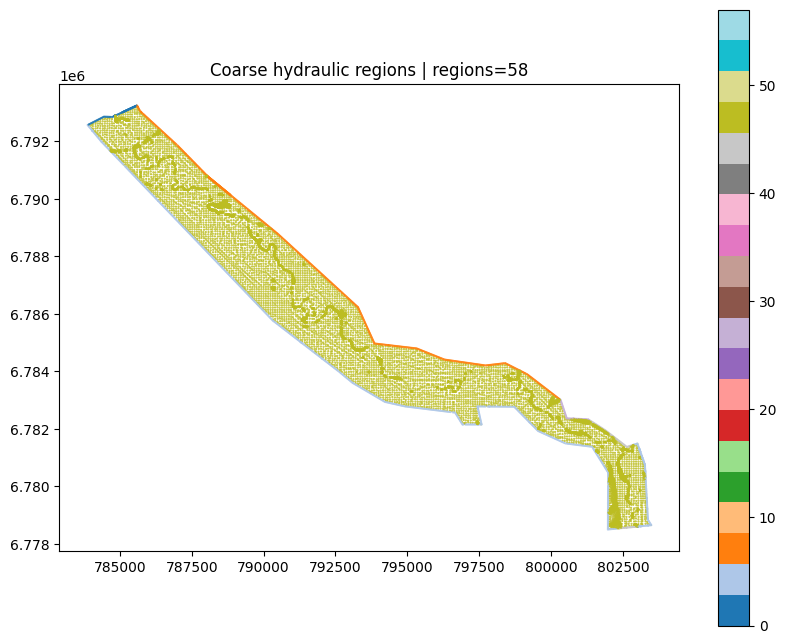

In [25]:
plot_regions(xy, coarse.region_id, 'Fine hydraulic regions')
plot_regions(coarse.xy, coarse.coarse_region_id, 'Coarse hydraulic regions')

## 9. Visualisation du support coarse

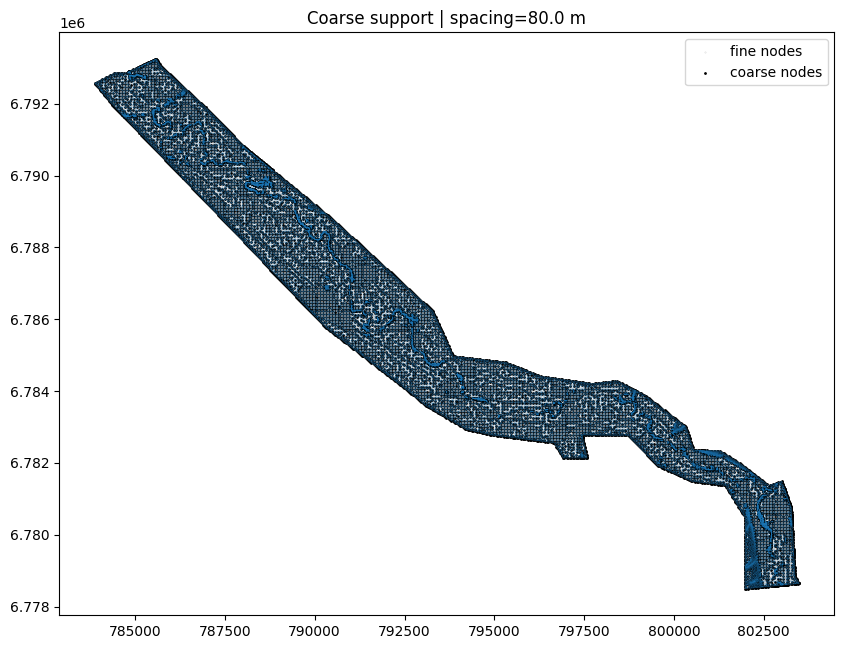

In [26]:
plot_coarse_support(
    fine_xy=xy,
    coarse_xy=coarse.xy,
    coarse_edges=coarse.undirected_edges,
    title=f'Coarse support | spacing={SPACING} m',
)

## 10. Triangulation Delaunay coarse

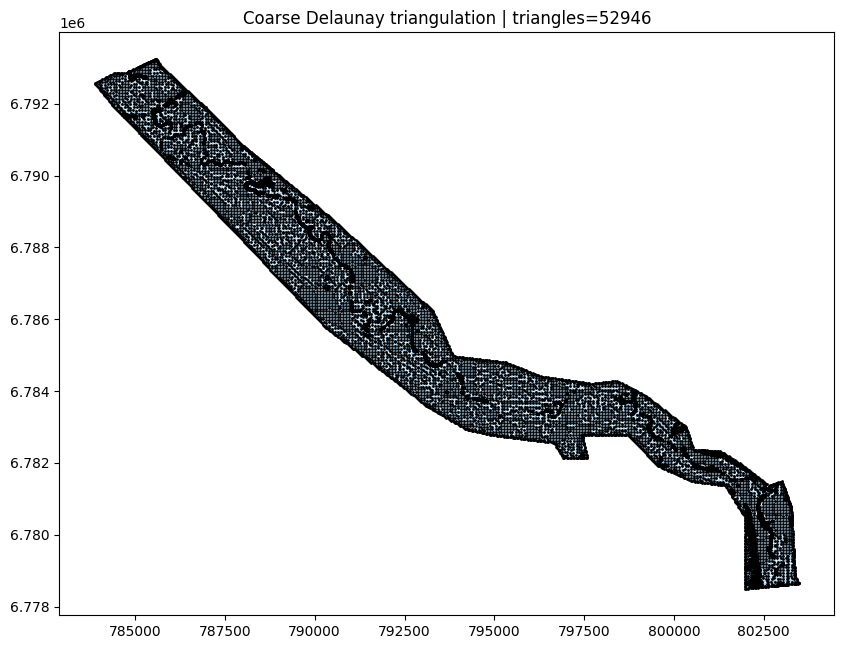

In [27]:
plot_coarse_triangulation(
    coarse_xy=coarse.xy,
    coarse_triangles=coarse.triangles,
    title='Coarse Delaunay triangulation',
)

## 11. Diagnostics des clusters

coarse nodes: 28820
mean cluster size: 10.878591256072172
median cluster size: 1.0
max cluster size: 892
singletons: 22230


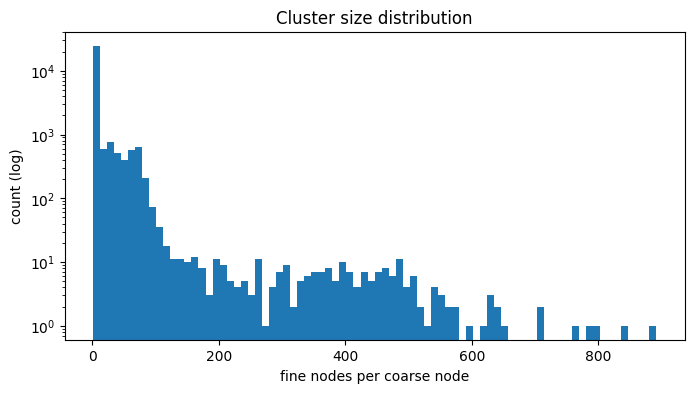

In [28]:
cluster_sizes = np.bincount(coarse.cluster)

print('coarse nodes:', len(cluster_sizes))
print('mean cluster size:', float(cluster_sizes.mean()))
print('median cluster size:', float(np.median(cluster_sizes)))
print('max cluster size:', int(cluster_sizes.max()))
print('singletons:', int((cluster_sizes == 1).sum()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cluster_sizes, bins=80, log=True)
ax.set_xlabel('fine nodes per coarse node')
ax.set_ylabel('count (log)')
ax.set_title('Cluster size distribution')
plt.show()

## 12. Projection de la topographie

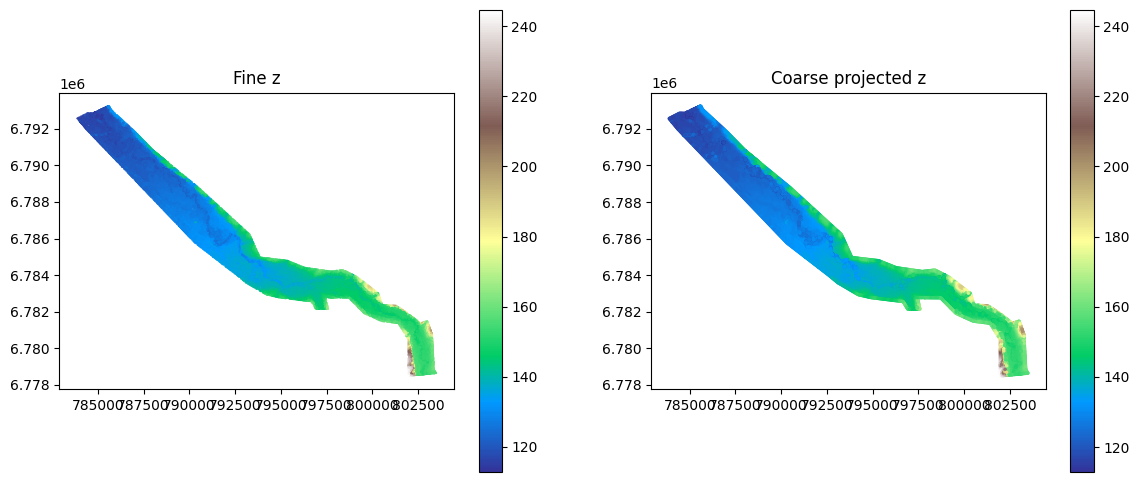

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

idx = sample_indices(len(xy), MAX_SCATTER_POINTS)
sc0 = axes[0].scatter(xy[idx, 0], xy[idx, 1], c=z[idx], s=0.2, cmap='terrain')
axes[0].set_aspect('equal')
axes[0].set_title('Fine z')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(coarse.xy[:, 0], coarse.xy[:, 1], c=coarse.z, s=2.0, cmap='terrain')
axes[1].set_aspect('equal')
axes[1].set_title('Coarse projected z')
plt.colorbar(sc1, ax=axes[1])

plt.show()

## 13. Export du maillage coarse en SLF

In [30]:
coarse_slf_path = write_coarse_slf(
    output_path=COARSE_SLF,
    coarse=coarse,
    overwrite=OVERWRITE_COARSE_SLF,
)

print('written:', coarse_slf_path)
print('nodes:', len(coarse.xy))
print('triangles:', len(coarse.triangles))

written: /work/m24046/m24046mrcr/Aube/automatic_coarse_mesh_T2.slf
nodes: 28820
triangles: 52946


## 14. Vérification rapide du SLF exporté

In [31]:
check_slf = TelemacFile(str(coarse_slf_path))

print('read nodes:', check_slf.npoin3)
print('read triangles:', check_slf.nelem3)
print('variables:', check_slf.varnames)
print('FOND range:', float(check_slf.get_data_value('FOND', 0).min()), float(check_slf.get_data_value('FOND', 0).max()))

if 'FROTTEMENT' in check_slf.varnames:
    strickler_check = check_slf.get_data_value('FROTTEMENT', 0)
    print('FROTTEMENT range:', float(strickler_check.min()), float(strickler_check.max()))

check_slf.close()

read nodes: 28820
read triangles: 52946
variables: ['FOND', 'FROTTEMENT']
FOND range: 112.90628051757812 244.6069793701172
FROTTEMENT range: 3.0 70.0
